# 07 Noise Atlas

Back in notebook 00 I was chasing a velocity estimate that would not sit still. At rest,
with the shaft mechanically stationary and the motor off, $\hat\omega$ was swinging by
hundreds of counts per second. Not drifting. Swinging. The obvious guess was a bug in the
observer, and I spent an evening looking for one that was not there.

The actual problem is that I never measured the noise. Every estimator downstream of here
needs to know how noisy each sensor is before it can weigh them against each other, and I
had been guessing. A Kalman filter without measured covariances is just a pole placement
with extra steps.

So this notebook is the atlas. For every channel the servo streams, at rest and under
drive, I want two things. How big is the noise, and what is it made of. The second question
turns out to matter more than I expected, because most of what looks like noise here is not
random at all. It is a small number of very specific tones.

For you busy folks, here is the short version:

- The pot is the noisy one. 8.7 counts of standard deviation sitting still.
- The current channel carries a tone at exactly 1250 Hz that has nothing to do with the motor.
- Under drive there is a strong commutation line that tracks speed, and it is a better
  tachometer than the pot by an order of magnitude.

## Picking a rig

Everything below reads from one dataset. A dataset is one board paired with one servo on
one supply, and its manifest names both, so the constants come from the capture rather than
from me remembering which board was on the bench that day.

Two tables print. The first is what the hardware is, the second is what somebody measured
when they looked. I keep them apart on purpose. A declared constant like a divider ratio is
a fact about the parts. A measured value is somebody's best estimate with a bracket around
it, and treating one like the other is how a fitted number quietly becomes a specification.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, detrend

import oscnb

# 2S is the primary dataset. USB droops under load (the rail falls 3.5% across the duty
# range and dips 22% on spin-up), so a fit against duty on USB folds rail droop into the
# duty axis. Every number in this notebook comes from 2S; USB appears only as a check that
# a trend points the same way.
ds = oscnb.use("sg90-a__dev-v006-D__2s")
board, servo = oscnb.current().board, oscnb.current().servo
FS = board.tick_hz          # 20 kHz, one telemetry sample per control tick

dataset  sg90-a__dev-v006-D__2s
supply   2s
rig      SG90 clone, unit A on osc-dev-v006 board D (bodged toward rev-2A)



,captures,recordings per capture,names
experiment,,,
breakaway,5,1,sweep
bridge,5,3,"fast, slow, spindown"
grid,10,1,sweep
reversal,5,1,sweep
ripple,5,1,sweep
stepcoast,5,5,"step120, step20, step40, step60, step80"



derived constants (what the hardware is)


value
where            quantity                                           unit                         
board            converter step                                     mV per count           0.8057
                 terminal divider ratio r                                                  3.0606
                 terminal difference                                mV per count           2.4658
                 terminal bias VB                                   mV                   627.9352
                                                                    counts               779.4008
                 driven-low terminal reads                          counts               524.7451
                 motor current                                      mA per count           0.8952
                                                                    counts per A        1117.0909
                 shunt                                              mOhm                  60.0000
                 amplifier gain                                     x                     15.0000
                 rail tap ratio                                                            2.5000
                 sample rate                                        samples per ms        20.0000
                 current settled from (UNVERIFIED)                  % duty                13.3333
                 voltage settled from (UNVERIFIED)                  % duty                13.3333
servo            pot intercept                                      counts               232.0000
                 pot slope                                          counts per degree     19.9600
                 envelope low                                       counts (10 deg)      431.6000
                 envelope high                                      counts (170 deg)    3625.2000
                 runway                                             counts              3193.6000
                 seek guard low                                     counts               432.0000
                 seek guard high                                    counts              3625.0000
servo (measured) gear_ratio_measured [234.73, 234.73] mechanical... :1                   234.7300
                 ripple_order_measured [6, 6] bringup isns-diff ... per motor rev          6.0000
                 kv_measured [7880, 8040] bringup isns-diff run28   RPM/V               7960.0000
                 kt_measured [1.19, 1.21] bringup isns-diff run28   mN-m/A                 1.2000
                 r_motor_measured [4.16, 4.24] bringup isns-diff... Ohm                    4.2000
                 l_motor_measured [0.45, 0.55] bringup isns-diff... mH                     0.5000
                 stall_current_measured [1.45, 1.55] bringup isn... A                      1.5000
                 stall_torque_measured [1.75, 1.85] bringup isns... mN-m                   1.8000
                 free_run_current_measured [0.078, 0.084] bringu... A                      0.0810
                 r_winding_measured [4.3, 4.8] nb03, full duty o... Ohm                    4.5000
                 pot_scale_measured [18.07, 18.49] ripple tach v... counts/deg            18.2900
                 coast_bemf_slope_measured [0.19, 0.204] nb01, c... V per wiper V/s        0.1970
                 ke_measured [7.29, 7.49] ripple speed + coast B... mV per motor rev/s     7.3670


measured values (what someone found when they looked)


value                 unit           bracket  \
where quantity                                                            
board vb_bias            781.000               counts        [775, 783]   
      rail_droop_usb      -3.500  % over 20-100% duty          [-4, -3]   
      opa_noise_floor      2.200           counts RMS          [2, 2.4]   
      esd_clamp_skew       1.800               V bemf        [1.7, 1.9]   
servo gear_ratio         234.730                   :1  [234.73, 234.73]   
      ripple_order         6.000        per motor rev            [6, 6]   
      kv                7960.000                RPM/V      [7880, 8040]   
      kt                   1.200               mN-m/A      [1.19, 1.21]   
      r_motor              4.200                  Ohm      [4.16, 4.24]   
      l_motor              0.500                   mH      [0.45, 0.55]   
      stall_current        1.500                    A      [1.45, 1.55]   
      stall_torque         1.800                 mN-m      [1.75, 1.85]   
      free_run_current     0.081                    A    [0.078, 0.084]   
      r_winding            4.500                  Ohm        [4.3, 4.8]   
      pot_scale           18.290           counts/deg    [18.07, 18.49]   
      coast_bemf_slope     0.197      V per wiper V/s     [0.19, 0.204]   
      ke                   7.367   mV per motor rev/s      [7.29, 7.49]   

                                                                   source  \
where quantity                                                              
board vb_bias                     Hi-Z rest baseline, 2S grid + stepcoast   
      rail_droop_usb                      2S vs USB grid, 5 captures each   
      opa_noise_floor                             bringup isns-diff run29   
      esd_clamp_skew                           bringup isns-diff findings   
servo gear_ratio                          mechanical/sg90/measurements.py   
      ripple_order                           bringup isns-diff runs 25-27   
      kv                                          bringup isns-diff run28   
      kt                                          bringup isns-diff run28   
      r_motor                                     bringup isns-diff run28   
      l_motor                                     bringup isns-diff run28   
      stall_current                               bringup isns-diff run28   
      stall_torque                                bringup isns-diff run28   
      free_run_current                            bringup isns-diff run28   
      r_winding                              nb03, full duty onset anchor   
      pot_scale         ripple tach vs counted gear ratio, 2S grid 30-...   
      coast_bemf_slope                                      nb01, chain 2   
      ke                ripple speed + coast BEMF, 2S bridge spindown,...   

                                                                   caveat  
where quantity                                                             
board vb_bias           nominal 779 from the 200/47 network, so 0.3%. ...  
      rail_droop_usb    USB also dips -21.8% transiently at 0.76 A; 2S...  
      opa_noise_floor   arm-B external network at G15; the internal PG...  
      esd_clamp_skew    above this the A-side ESD clamp skews the divi...  
servo gear_ratio        (47*38*32*23)/(10*10*8*7), counted teeth on th...  
      ripple_order      3-segment commutator x 2 brushes; optical tach...  
      kv                bare can, +/-1% HSI scale; pinion stayed on th...  
      kt                                                                   
      r_motor           bare can. nb03 got 4.5 [4.3, 4.8] in-servo via...  
      l_motor                            locked-rotor burst, tau_e 102 us  
      stall_current                                       = V/R confirmed  
      stall_torque                                                         
      free_run_current                                         at duty 65

## What the channels are

Six values come off the wire per tick. Three of them are raw ADC readings and the rest are
things the kernel worked out.

- **pos** is the feedback potentiometer wiper, in ADC counts. It measures the OUTPUT shaft,
  after the gearbox.
- **current_raw** and **current_trough** are the shunt amplifier sampled at the two ends of
  the PWM period. Under slow decay the crest sample sits in the driven half and the trough
  sample sits in the braked half.
- **vmotor_a** and **vmotor_b** are the two motor terminals, each through a divider that
  returns to a small bias node so both terminals stay inside the ADC range even when one
  swings negative.
- **duty_q15** is what the kernel actually commanded, which is not always what I asked for.

The difference `vmotor_a - vmotor_b` is free of the bias by construction, because both
dividers return to the same node. That is worth knowing because it means terminal voltage
DIFFERENCES are trustworthy in a way that single terminal readings are not.

## The noise floor at rest

Start with the easy measurement. Every capture opens with a one second baseline burst at
zero duty, motor off, shaft stationary. Whatever moves during that second is noise.

I take the standard deviation per channel per capture, then report the spread across the
five captures, because the proof rule for this project is that the control synthesis
consumes the SPREAD and not the nominal. One capture tells me a number. Five tell me
whether to believe it.

In [2]:
def rest_frame(dataset, experiment="grid"):
    # One row per capture per channel: the standard deviation over the zero-duty baseline.
    rows = []
    for cap in dataset.captures(experiment):
        df = dataset.read(experiment, cap, "sweep")
        rest = df[df.cmd_duty_q15 == 0]
        for ch in ("pos", "current_raw", "current_trough", "vmotor_a", "vmotor_b"):
            rows.append({"capture": cap, "channel": ch,
                         "mean": rest[ch].mean(), "sd_counts": rest[ch].std()})
    return pd.DataFrame(rows)

rest = rest_frame(ds)
# Convert each channel's count noise into the unit a human thinks in. pos stays in counts
# because converting it needs the pot scale, which notebook 06 shows is itself disputed.
UNITS = {"pos": (1.0, "counts"),
         "current_raw": (board.a_per_count * 1e3, "mA"),
         "current_trough": (board.a_per_count * 1e3, "mA"),
         "vmotor_a": (board.v_adc_per_count * 1e3, "mV at the pin"),
         "vmotor_b": (board.v_adc_per_count * 1e3, "mV at the pin")}

summary = rest.groupby("channel")["sd_counts"].agg(["mean", "std", "min", "max"])
summary["unit"] = [UNITS[c][1] for c in summary.index]
summary["sd in unit"] = [summary.loc[c, "mean"] * UNITS[c][0] for c in summary.index]
summary.round(3)

,mean,std,min,max,unit,sd in unit
channel,,,,,,
current_raw,1.031,0.024,0.998,1.071,mA,0.923
current_trough,1.107,0.078,1.010,1.259,mA,0.991
pos,8.040,0.778,6.811,9.238,counts,8.040
vmotor_a,15.772,0.539,14.794,16.584,mV at the pin,12.707
vmotor_b,21.986,0.794,20.525,23.217,mV at the pin,17.714


The pot is the loud one, and it is not close. Nearly nine counts of standard deviation while
the shaft is mechanically stopped.

That number is the whole answer to the mystery I opened with. If you estimate speed by
differencing consecutive pot samples one tick apart, you are dividing a noise of roughly
9 counts by a time step of 50 microseconds. That is an apparent speed of around 175,000
counts per second of pure garbage, from a shaft that is not moving. Any velocity estimate
built on the raw pot derivative is dominated by this, which is exactly why $\hat\omega$
rails at rest.

The current channel is quiet by comparison, about 1 mA. The terminal channels sit in
between.

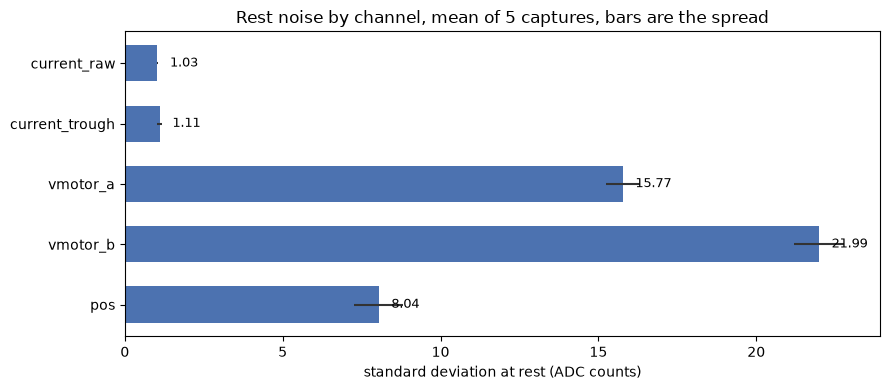

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
order = ["pos", "vmotor_b", "vmotor_a", "current_trough", "current_raw"]
for i, ch in enumerate(order):
    d = rest[rest.channel == ch]["sd_counts"]
    ax.barh(i, d.mean(), xerr=d.std(), color="#4c72b0", height=0.6, error_kw=dict(ecolor="#333"))
    ax.text(d.mean() + 0.4, i, f"{d.mean():.2f}", va="center", fontsize=9)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
ax.set_xlabel("standard deviation at rest (ADC counts)")
ax.set_title("Rest noise by channel, mean of 5 captures, bars are the spread")
plt.tight_layout(); plt.show()

**What you are looking at:** how much each channel wobbles with the motor off and the shaft
still, in raw ADC counts so the channels are directly comparable. The error bar is the
spread across five captures, which is small everywhere, so these are stable numbers rather
than one lucky recording.

## What the noise is made of

A standard deviation tells me how big the noise is but nothing about its shape, and for a
filter the shape is what matters. White noise averages away. A tone does not.

So here is the spectrum of the current channel over that same at rest second. If the noise
were random I would expect a flat floor with nothing sticking out.

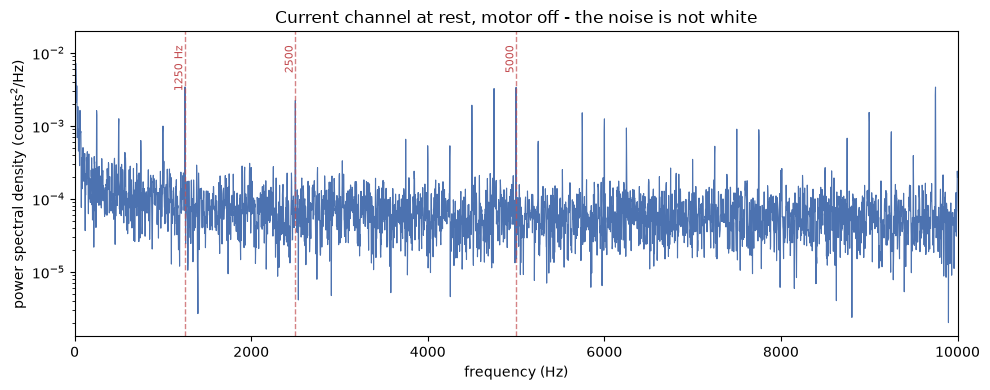

In [4]:
rest_df = ds.read("grid", "capture-1", "sweep")
x = detrend(rest_df[rest_df.cmd_duty_q15 == 0].current_raw.values.astype(float))
f, P = welch(x, fs=FS, nperseg=8192)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(f, P, lw=0.8, color="#4c72b0")
for line, label in ((1250, "1250 Hz"), (2500, "2500"), (5000, "5000")):
    ax.axvline(line, color="#c44e52", ls="--", lw=1, alpha=0.7)
    ax.text(line, P.max(), label, rotation=90, va="top", ha="right", fontsize=8, color="#c44e52")
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("power spectral density (counts$^2$/Hz)")
ax.set_title("Current channel at rest, motor off - the noise is not white")
ax.set_xlim(0, FS / 2)
plt.tight_layout(); plt.show()

**What you are looking at:** the current channel's noise spread out by frequency, with the
motor off. A flat line would mean random noise. Instead there is a spike at 1250 Hz and
more at its multiples.

That 1250 Hz is not the motor, because the motor is not turning. The sample rate is 20 kHz
and $20000/16 = 1250$, so this is something happening once every sixteen ticks, locked to
the tick clock rather than to the shaft.

It is the telemetry bus. This board is a hand modified development board, and on it the
current sense amplifier output runs near the data line. A scope on the amplifier output
shows every bus data edge as a +30 / -20 mV spike, so this is measured, not inferred. The
telemetry goes out in sixteen sample bursts synchronous with the control tick, which is why
the disturbance lands at a fixed phase and appears as a tone instead of as hash.

Now the part that surprised me. The prescribed check for this is whether the resting current
is flat across the tick position within the burst, and it passes.

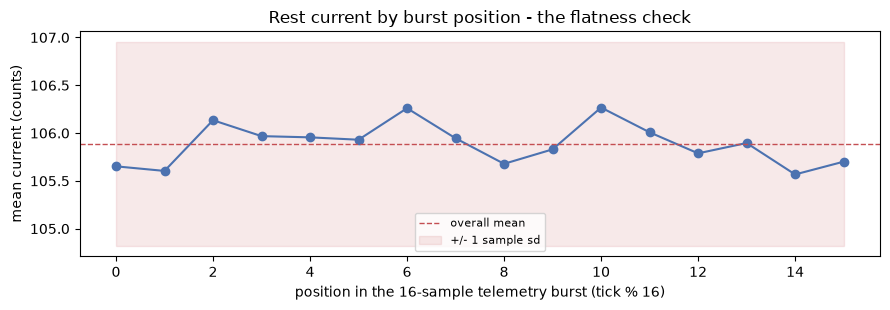

spread across burst positions: 0.70 counts
single sample sd:              1.07 counts


In [5]:
# The standard check for this rig: rest current grouped by position in the 16-sample
# telemetry burst must be flat. Aperture variants that landed a bus byte on the 73 ns shunt
# sample tripled the rest noise to 3-5 counts; the build these captures came from does not.
rest_only = rest_df[rest_df.cmd_duty_q15 == 0]
by_tick = rest_only.groupby(rest_only.tick % 16).current_raw.mean()

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(by_tick.index, by_tick.values, "o-", color="#4c72b0")
ax.axhline(rest_only.current_raw.mean(), color="#c44e52", ls="--", lw=1, label="overall mean")
band = rest_only.current_raw.std()
ax.fill_between([0, 15], rest_only.current_raw.mean() - band, rest_only.current_raw.mean() + band,
                color="#c44e52", alpha=0.12, label="+/- 1 sample sd")
ax.set_xlabel("position in the 16-sample telemetry burst (tick % 16)")
ax.set_ylabel("mean current (counts)"); ax.legend(fontsize=8)
ax.set_title("Rest current by burst position - the flatness check")
plt.tight_layout(); plt.show()

print(f"spread across burst positions: {by_tick.max() - by_tick.min():.2f} counts")
print(f"single sample sd:              {rest_only.current_raw.std():.2f} counts")

**What you are looking at:** the average resting current at each of the sixteen positions
within a telemetry burst. If a bus byte were landing on the shunt sample, one group of
positions would sit clearly above the others. The shaded band is one sample standard
deviation for scale.

The structure spans about 0.7 counts against a sample noise of 1.07, so it is real but
smaller than the noise it hides in. That is the resolution of the apparent contradiction:
the coupling is genuinely there and genuinely tiny, and it shows up as a strong spectral
line anyway because a spectrum concentrates a repeating pattern into one bin while spreading
random noise across all of them.

Which is the argument for this whole notebook in one picture. A standard deviation of 1 mA
looks excellent and hides a deterministic component that will not average away with more
samples. You have to look at the shape.

The practical rules that fall out, both of which are rig limitations rather than facts about
the design:

- This build is usable, and the check above is what says so. It should be re-run after any
  change to scan length or aperture, because those move the byte grid and the current
  geometry is clean partly by luck.
- Current derived numbers on this board still carry a systematic that their noise floor does
  not show. A future revision separates the bus from the amplifier and adds an input RC.

In [6]:
def top_lines(sig, fs=FS, nperseg=8192, n=6, sep=40.0, fmin=1.0):
    # Strongest spectral lines, keeping them at least `sep` Hz apart so one broad peak does
    # not fill the whole list with its own shoulders.
    f, P = welch(detrend(sig.astype(float)), fs=fs, nperseg=min(nperseg, len(sig)))
    med = np.median(P)
    out = []
    for i in np.argsort(P)[::-1]:
        if f[i] < fmin or any(abs(f[i] - g[0]) < sep for g in out):
            continue
        out.append((f[i], P[i] / med))
        if len(out) >= n:
            break
    return out

rows = []
for ch in ("pos", "current_raw", "current_trough", "vmotor_a", "vmotor_b"):
    sig = rest_df[rest_df.cmd_duty_q15 == 0][ch].values
    for hz, prom in top_lines(sig):
        rows.append({"channel": ch, "Hz": round(hz, 1), "x median": round(prom, 1)})
pd.DataFrame(rows).set_index(["channel", "Hz"])

x median
channel        Hz              
pos            2.4      24463.3
               2500.0    2550.5
               3750.0    1874.1
               3999.0    1739.5
               1999.5    1037.5
               3249.5    1013.6
current_raw    2.4        199.2
               1250.0      53.4
               9751.0      53.2
               5000.0      52.7
               4751.0      50.8
               2500.0      34.9
current_trough 5000.0     288.7
               249.0      156.0
               2.4        154.8
               500.5      106.0
               749.5       86.7
               5249.0      65.6
vmotor_a       2.4     168859.9
               2500.0     386.6
               3750.0     314.9
               3999.0     149.7
               3249.5     141.2
               1999.5     133.2
vmotor_b       2.4     241207.8
               2500.0     429.9
               3750.0     305.1
               3999.0     260.1
               3249.5     141.1
               1999.5     124.0

## Under drive, a line that means something

At rest the only tones are artefacts. Under drive a different line appears, and this one is
the motor telling me how fast it is spinning.

A brushed can commutates. This motor has three windings and two brushes, so each of the
three commutator segment boundaries passes each brush once per revolution, giving six
current spikes per revolution. That divisor is a parts count from a teardown, not a guess,
and an optical tachometer agreed with it to 0.7%.

So if I find that line and divide by six, I have the motor shaft speed, measured on the
electrical side, without touching the pot.

In [7]:
GEAR = servo.measured["gear_ratio_measured"].value    # 234.73:1, counted teeth

def ripple_hz(g, lo=1400.0, hi=5200.0):
    # The 6/rev commutation line. Search only the band it can actually occupy: a bare argmax
    # from DC happily locks onto a subharmonic and gives an answer that looks plausible and
    # is wrong by an integer factor.
    f, P = welch(detrend(g.current_raw.values.astype(float)), fs=FS, nperseg=min(4096, len(g)))
    m = (f > lo) & (f < hi)
    return f[m][np.argmax(P[m])]

def pot_speed(g, half=40):
    # Counts per ms from the pot. The window is deliberately wide: pos is integer counts, so
    # differencing over one millisecond quantises the answer into steps that are a large
    # fraction of the value being measured.
    p = g.pos.values.astype(float)
    return np.median(np.abs(p[2 * half:] - p[:-2 * half]) / (2 * half / (FS / 1000)))

rows = []
for cap in ds.captures("grid"):
    df = ds.read("grid", cap, "sweep")
    for seg, g in df.groupby("seg"):
        g = g.sort_values("tick")
        duty = round(abs(int(g.cmd_duty_q15.iloc[0])) / 32767 * 100)
        if duty not in (30, 35, 40, 45) or int(g.dir.iloc[0]) != 1 or len(g) < 2500:
            continue
        f6 = ripple_hz(g)
        rows.append({"capture": cap, "duty": duty, "ripple_hz": f6,
                     "motor_rev_s": f6 / 6, "pot_counts_ms": pot_speed(g)})
drive = pd.DataFrame(rows)
drive.groupby("duty")[["ripple_hz", "motor_rev_s", "pot_counts_ms"]].agg(["mean", "std"]).round(2)

ripple_hz        motor_rev_s       pot_counts_ms      
          mean    std        mean   std          mean   std
duty                                                       
30     1572.27   9.49      262.04  1.58          7.38  0.13
35     1888.67  10.24      314.78  1.71          8.82  0.12
40     2183.11  13.51      363.85  2.25         10.25  0.00
45     2482.42  12.44      413.74  2.07         11.52  0.08

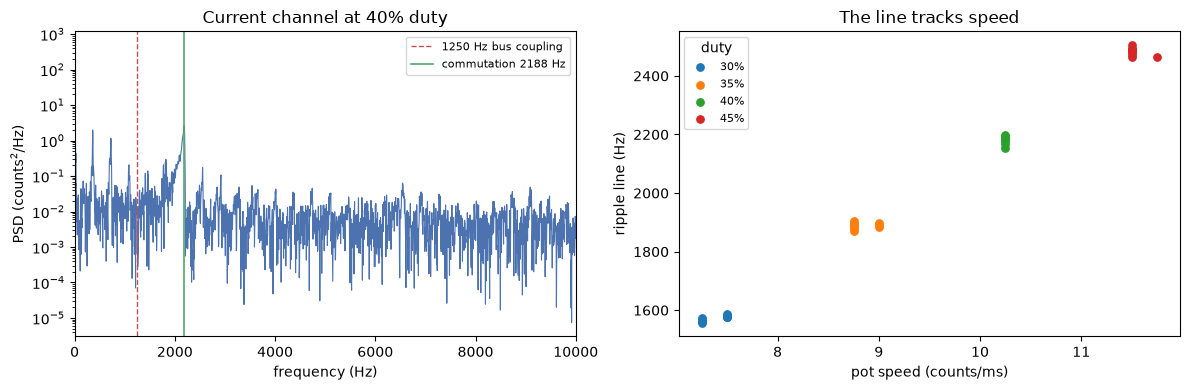

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
g = ds.read("grid", "capture-1", "sweep")
g = g[(g.cmd_duty_q15.abs() / 32767 * 100).round() == 40]
g = g[g.dir == 1]
f, P = welch(detrend(g.current_raw.values.astype(float)), fs=FS, nperseg=4096)
axes[0].semilogy(f, P, lw=0.8, color="#4c72b0")
axes[0].axvline(1250, color="#c44e52", ls="--", lw=1, label="1250 Hz bus coupling")
pk = f[(f > 1400) & (f < 5200)][np.argmax(P[(f > 1400) & (f < 5200)])]
axes[0].axvline(pk, color="#55a868", ls="-", lw=1.2, label=f"commutation {pk:.0f} Hz")
axes[0].set_xlabel("frequency (Hz)"); axes[0].set_ylabel("PSD (counts$^2$/Hz)")
axes[0].set_title("Current channel at 40% duty"); axes[0].legend(fontsize=8); axes[0].set_xlim(0, FS / 2)

for d, sub in drive.groupby("duty"):
    axes[1].scatter(sub.pot_counts_ms, sub.ripple_hz, label=f"{d}%", s=28)
axes[1].set_xlabel("pot speed (counts/ms)"); axes[1].set_ylabel("ripple line (Hz)")
axes[1].set_title("The line tracks speed"); axes[1].legend(title="duty", fontsize=8)
plt.tight_layout(); plt.show()

**What you are looking at:** on the left, the same current channel as before but now with
the motor turning at 40% duty. The red dashed line is the bus artefact, still sitting at
1250 Hz where it always is. The green line is new, and it moves when the motor speed moves.

On the right, that green line's frequency plotted against the speed the pot reports, for
four duties across five captures. It is a straight line through the origin, which is what a
real tachometer signal looks like.

The two tones behave completely differently and that difference is how you tell them apart.
The artefact is nailed to the tick clock. The commutation line is nailed to the shaft.

## How much better is the electrical speed axis

Both channels claim to measure speed, so let me put a number on which one to believe. For
each rung I have the ripple line and the pot derivative over the same samples. If the
gearbox and the pot were perfect, the ratio between them would be a constant, because the
gear ratio is fixed at 234.73 to 1 by counted teeth.

In [9]:
# Output revolutions per second from the electrical side, then how many pot counts the pot
# actually reported per output revolution. With a fixed gear ratio this should be constant.
drive["out_rev_s"] = drive.motor_rev_s / GEAR
drive["counts_per_rev"] = drive.pot_counts_ms * 1000 / drive.out_rev_s
drive["counts_per_deg"] = drive.counts_per_rev / 360

cv = drive.counts_per_deg.std() / drive.counts_per_deg.mean() * 100
print(f"pot scale from the ripple axis: {drive.counts_per_deg.mean():.2f} counts/deg"
      f"   sd {drive.counts_per_deg.std():.2f}   CV {cv:.1f}%   n={len(drive)}")
print(f"declared in servos.py:          {servo.pos_per_deg:.2f} counts/deg"
      f"   ({(servo.pos_per_deg / drive.counts_per_deg.mean() - 1) * 100:+.1f}%)")
print()
print(f"full 4096-count pot span: {4096 / drive.counts_per_deg.mean():.0f} deg measured,"
      f" {4096 / servo.pos_per_deg:.0f} deg if the declared scale were right")

pot scale from the ripple axis: 18.29 counts/deg   sd 0.21   CV 1.2%   n=40
declared in servos.py:          19.96 counts/deg   (+9.1%)

full 4096-count pot span: 224 deg measured, 205 deg if the declared scale were right


The ratio holds to about one percent WITHIN this set of rungs, which is tight. But I have to
be careful about what that tightness means, because notebook 06 already measured this exact
quantity and got a different answer.

Notebook 06 reports 253 ripple cycles per wiper volt, travel weighted across the span, with
a 4.6% spread. The same quantity from these rungs comes out at 265.5, which is 4.9% higher
and just outside that spread.

The reason is notebook 06's main finding, and it is the thing to take away from this
section. **The pot's local gain is not constant.** It swings between 1.9 and 7.2 mV per
ripple cycle depending on where the shaft is, a factor of 3.7, and the pattern is a fixed
function of position rather than noise. Repeat traces lay on top of each other.

So there is no single number here to be right about. My rungs sweep one range of positions
and notebook 06 weighted the whole travel, and both are averages of a function that varies
by nearly four times underneath them. The declared 19.96 counts per degree, notebook 06's
253 cycles per wiper volt and my 265.5 are three different weightings, and they land within
9% of each other for that reason and no deeper one.

I had this wrong earlier in the evening. I read the tight one percent agreement inside my
own rungs as evidence that I had measured the pot scale and that the declared value was
simply nine percent off. Consistency across duties is not the same as accuracy across
position, and my rungs were not varied enough in position to notice.

What the observer actually needs is not a better single number, it is the local gain map,
or an acceptance that a pot derived speed carries a disturbance with a period of about
0.17 wiper volts. That is notebook 06's conclusion and this notebook does not improve on it.

## Covariances for the observer

This is the output the next notebook actually consumes. A Kalman filter needs a measurement
noise variance per sensor, and these are those numbers, measured rather than tuned by feel.

I report variance in the sensor's own units, plus what the pot's noise turns into if you
differentiate it, because that conversion is the entire reason the velocity estimate
misbehaves.

In [10]:
cov = []
for ch in ("pos", "current_raw", "current_trough", "vmotor_a", "vmotor_b"):
    sd = rest[rest.channel == ch]["sd_counts"]
    cov.append({"channel": ch, "sd (counts)": sd.mean(), "variance (counts^2)": sd.mean() ** 2,
                "spread across captures": sd.std()})
cov = pd.DataFrame(cov).set_index("channel").round(3)

pos_sd = rest[rest.channel == "pos"]["sd_counts"].mean()
dt = 1.0 / FS
print(f"pot noise differentiated one tick apart: {pos_sd * np.sqrt(2) / dt:,.0f} counts/s of"
      f" apparent speed, from a stationary shaft")
print(f"the same noise over a 4 ms window:       {pos_sd * np.sqrt(2) / 0.004:,.0f} counts/s")
print()
cov

pot noise differentiated one tick apart: 227,414 counts/s of apparent speed, from a stationary shaft
the same noise over a 4 ms window:       2,843 counts/s



,sd (counts),variance (counts^2),spread across captures
channel,,,
pos,8.040,64.646,0.778
current_raw,1.031,1.063,0.024
current_trough,1.107,1.226,0.078
vmotor_a,15.772,248.764,0.539
vmotor_b,21.986,483.401,0.794


Widening the differencing window from one tick to four milliseconds knocks the apparent
speed noise down by nearly two orders of magnitude, which is why every speed figure in this
notebook uses a wide window. It also costs bandwidth, and that trade is what notebook 08
has to make properly rather than by hand.

## Caveats

Things that are true of this rig and should not be mistaken for facts about the design.

- **The current channel carries a 1250 Hz tone from bus coupling.** The board is a hand
  modified development board with the sense amplifier output running near the data line.
  This is a board limitation, not a property of the servo, and a future revision moves the
  bus away. Any current derived number here carries a systematic that its standard
  deviation does not show.
- **The pot scale is position dependent, not a constant.** Notebook 06 measures the local
  gain swinging 3.7x across the travel. Any single counts per degree figure, including the
  18.29 in this notebook, is an average over whichever positions the rungs happened to
  cover. Treat degree and radian per second figures on this servo as carrying several
  percent from this alone. Counts are unaffected.
- **The commutation line is only clean between about 30 and 45 percent duty.** Below that
  the motor barely turns. Above about 50 percent a three per revolution subharmonic starts
  to dominate the six per revolution fundamental, and a naive peak search silently returns
  half the right answer.
- **This is one servo.** Motor constants in this clone family vary widely enough that the
  parts listing and a measured unit disagree by a third, so none of these numbers should be
  copied to another servo without re-measuring.

## Open questions, and what would settle them

Each of these is a discrepancy I found and could not close with the data I have. For each
one I have written down what could cause it and the experiment that would tell the causes
apart, because a cause with no discriminating experiment is a story rather than a
hypothesis.

**1. There may be no single pot scale to find.** Eyeballed horn angles imply 19.96 counts
per degree, notebook 06's travel weighted ripple gives about 19.2, and these rungs give
18.29. Notebook 06 also shows the local gain varying 3.7x with position.

*Causes:* the three numbers are different position weightings of one nonlinear function, and
all are "right" for their own weighting; or one of the three has a systematic on top of that.
*Discriminator:* sweep the ripple measurement across position bins within single long rungs
and compare the resulting local gain curve against notebook 06's map. If the curves overlay,
the spread is fully explained by weighting and the correction table is the answer. If mine is
offset as a whole, something else is also going on. Separately, a printed protractor at the
envelope ends gives an absolute angle reference, which is the only thing here that can
re-anchor the offset rather than the slope.

**2. A reconstructed velocity observer reads about six percent high.** Building
$\hat\omega = (v_\text{mean} - R\,i_\text{mean})/K_e$ from the drive samples and scoring it
against the ripple line gives a consistent positive bias with only 1.3% scatter.

*Causes:* the mean terminal voltage is overestimated, because I model the braked half of the
PWM period as zero volts when it actually reads 40 to 120 mV; or the mean current is
underestimated, because averaging the two end samples is not a true period average; or the
inductive term was not properly removed.
*Discriminator:* these predict different things. Voltage overestimation shrinks as duty
rises and the off time shortens. Current underestimation scales with load. The inductive
term varies with sampling phase. The measured bias does fall from 8.3% to 5.1% between 30%
and 45% duty, which leans toward the first, but four points is not a result.

**3. The winding resistance has two values.** 4.2 ohm measured on a bare can on the bench,
4.5 ohm measured in the assembled servo.

*Causes:* they are genuinely different measurements of different things, one of them being a
motor sitting in a warm gearbox; or one method has a systematic.
*Discriminator:* measure resistance in the servo cold and again after a long run. If the
gap tracks temperature at the copper coefficient of 0.393% per degree, it is thermal and
both numbers are right at their own temperatures.

## Where this goes next

Notebook 08 takes the covariance table above and runs the observer bake off properly, with
the pot derivative, the model based back-EMF estimate, the direct back-EMF reading and the
ripple tachometer all scored against each other on the same captures.

The thing I would keep from this one is smaller than the tables. Most of what looked like
noise turned out to be structure. One tone was the bus talking to the amplifier and one was
the motor telling me its speed, and until I looked at the spectra they were both just
variance. It is worth plotting the shape before trusting the size.